Cell 1: Environment Setup & Imports

In [3]:
%%capture --no-stdout --no-display
import os
# Set these levels BEFORE importing any TensorFlow/Keras libraries
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
os.environ['ABSL_LOGGING_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf

import glob
import time
import random
import warnings
from pathlib import Path
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from PIL import Image

import shap

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid')
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


Cell 2: Centralized Configuration

In [4]:
# %% [code]
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
MAX_IMAGES_PER_CLASS = 800
INITIAL_EPOCHS = 8
FINE_TUNE_EPOCHS = 5
FINE_TUNE_LAST_N = 30

ROLE_NAMES = ['Goalkeeper', 'Defender', 'Midfielder', 'Forward']
ROLE_TO_ID = {name: idx for idx, name in enumerate(ROLE_NAMES)}
ID_TO_ROLE = {idx: name for name, idx in ROLE_TO_ID.items()}

WORK_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
IMAGE_DIR = WORK_DIR / 'images'
FIGURE_DIR = WORK_DIR / 'figures'
TABLE_DIR = WORK_DIR / 'tables'
MODEL_DIR = WORK_DIR / 'models'

for directory in [IMAGE_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("✓ Environment and hyperparameter configuration complete.")

✓ Environment and hyperparameter configuration complete.


Cell 3: Load Dataset and Map Football Positions to Roles

In [5]:
# %% [code]
def find_players_csv():
    candidates = glob.glob('/kaggle/input/**/players_22.csv', recursive=True)
    if not candidates:
        candidates = glob.glob('**/players_22.csv', recursive=True)
    if not candidates:
        raise FileNotFoundError('Could not find players_22.csv. Please attach the dataset to your Kaggle environment.')
    return candidates[0]

csv_path = find_players_csv()

# Added low_memory=False to scan all rows at once and prevent mixed-type DtypeWarnings
df = pd.read_csv(csv_path, low_memory=False)

POSITION_TO_ROLE = {
    'GK': 'Goalkeeper',
    'CB': 'Defender', 'LB': 'Defender', 'RB': 'Defender',
    'LCB': 'Defender', 'RCB': 'Defender', 'LWB': 'Defender', 'RWB': 'Defender',
    'CM': 'Midfielder', 'CDM': 'Midfielder', 'CAM': 'Midfielder', 'LM': 'Midfielder', 'RM': 'Midfielder',
    'LCM': 'Midfielder', 'RCM': 'Midfielder', 'LDM': 'Midfielder', 'RDM': 'Midfielder',
    'LAM': 'Midfielder', 'RAM': 'Midfielder',
    'ST': 'Forward', 'CF': 'Forward', 'LW': 'Forward', 'RW': 'Forward',
    'LF': 'Forward', 'RF': 'Forward', 'LS': 'Forward', 'RS': 'Forward',
}

def primary_position(position_text):
    if pd.isna(position_text):
        return None
    return str(position_text).split(',')[0].strip()

df['primary_position'] = df['player_positions'].apply(primary_position)
df['role'] = df['primary_position'].map(POSITION_TO_ROLE)

role_df = df.dropna(subset=['role', 'player_face_url']).copy()
role_df = role_df[['sofifa_id', 'short_name', 'primary_position', 'role', 'player_face_url']]
role_df['label'] = role_df['role'].map(ROLE_TO_ID)
role_df = role_df.drop_duplicates(subset=['sofifa_id'])

role_counts = role_df['role'].value_counts().reindex(ROLE_NAMES).fillna(0).astype(int)
role_counts_df = role_counts.rename_axis('role').reset_index(name='csv_count')
role_counts_df.to_csv(TABLE_DIR / 'role_counts_from_csv.csv', index=False)

print("\nDataset Class Distribution:")
print(role_counts_df.to_string(index=False))


Dataset Class Distribution:
      role  csv_count
Goalkeeper       2132
  Defender       6394
Midfielder       7033
   Forward       3680


Cell 4: Visualize Class Distributions

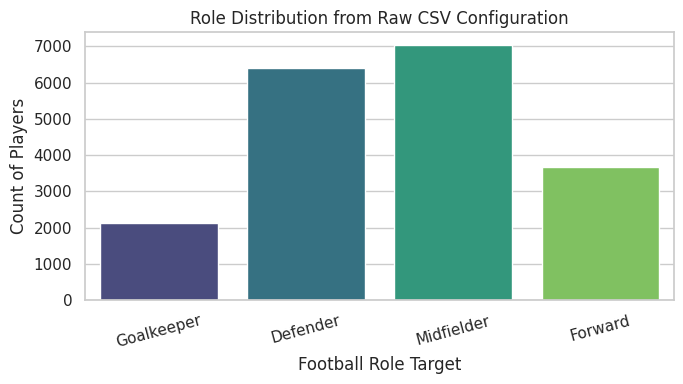

In [6]:
# %% [code]
plt.figure(figsize=(7, 4))
sns.barplot(data=role_counts_df, x='role', y='csv_count', hue='role', palette='viridis', legend=False)
plt.title('Role Distribution from Raw CSV Configuration')
plt.xlabel('Football Role Target')
plt.ylabel('Count of Players')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'role_counts_before_download.pdf', format='pdf', bbox_inches='tight')
plt.show()

Cell 5: Resilient Parallel Downloader and Image Validator

In [7]:
# %% [code]
def image_extension_from_url(url):
    suffix = Path(urlparse(url).path).suffix.lower()
    return suffix if suffix in ['.jpg', '.jpeg', '.png'] else '.jpg'

def validate_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

def download_image(url, destination, timeout=10, retries=2):
    if destination.exists() and validate_image(destination):
        return True
    for attempt in range(retries + 1):
        try:
            response = requests.get(url, timeout=timeout, headers={'User-Agent': 'Mozilla/5.0'})
            if response.status_code == 200 and response.content:
                destination.write_bytes(response.content)
                if validate_image(destination):
                    return True
                destination.unlink(missing_ok=True)
        except Exception:
            time.sleep(0.2)
    return False

download_records = []

for role in ROLE_NAMES:
    role_dir = IMAGE_DIR / role
    role_dir.mkdir(parents=True, exist_ok=True)
    role_candidates = role_df[role_df['role'] == role].sample(frac=1, random_state=SEED).reset_index(drop=True)
    success_count = 0
    print(f'Downloading {role} assets...')
    
    for _, row in role_candidates.iterrows():
        if success_count >= MAX_IMAGES_PER_CLASS:
            break
        ext = image_extension_from_url(row['player_face_url'])
        image_path = role_dir / f"{int(row['sofifa_id'])}{ext}"
        
        if download_image(row['player_face_url'], image_path):
            download_records.append({
                'image_path': str(image_path),
                'sofifa_id': row['sofifa_id'],
                'short_name': row['short_name'],
                'primary_position': row['primary_position'],
                'role': role,
                'label': ROLE_TO_ID[role]
            })
            success_count += 1
            
        if success_count % 200 == 0 and success_count > 0:
            print(f'  -> {role}: {success_count} images secured')
            
    print(f'Completed {role}: {success_count} validated images ready.')

image_df = pd.DataFrame(download_records)
image_df.to_csv(TABLE_DIR / 'downloaded_images_raw.csv', index=False)

download_counts = image_df['role'].value_counts().reindex(ROLE_NAMES).fillna(0).astype(int)
download_counts_df = download_counts.rename_axis('role').reset_index(name='downloaded_count')
print('\nFinalized Live Asset Counts:')
print(download_counts_df.to_string(index=False))

  -> Goalkeeper: 200 images secured
  -> Goalkeeper: 400 images secured
  -> Goalkeeper: 600 images secured
  -> Goalkeeper: 800 images secured
Completed Goalkeeper: 800 validated images ready.
  -> Defender: 200 images secured
  -> Defender: 400 images secured
  -> Defender: 600 images secured
  -> Defender: 800 images secured
Completed Defender: 800 validated images ready.
  -> Midfielder: 200 images secured
  -> Midfielder: 200 images secured
  -> Midfielder: 400 images secured
  -> Midfielder: 600 images secured
  -> Midfielder: 800 images secured
Completed Midfielder: 800 validated images ready.
  -> Forward: 200 images secured
  -> Forward: 400 images secured
  -> Forward: 600 images secured
  -> Forward: 800 images secured
Completed Forward: 800 validated images ready.

Finalized Live Asset Counts:
      role  downloaded_count
Goalkeeper               800
  Defender               800
Midfielder               800
   Forward               800


Cell 6: Dataset Stratification & Splits

In [9]:
# %% [code]
min_class_count = int(image_df['role'].value_counts().min())
balanced_count = min(MAX_IMAGES_PER_CLASS, min_class_count)
print('Balanced target count per class:', balanced_count)

# Clean, modern pandas implementation without deprecated .apply() structures
balanced_df = (
    image_df.groupby('role', as_index=False)
    .sample(n=balanced_count, random_state=SEED)
    .sample(frac=1, random_state=SEED)  # Reshuffle entire dataset row ordering
    .reset_index(drop=True)
)

balanced_df['label'] = balanced_df['role'].map(ROLE_TO_ID)

train_df, temp_df = train_test_split(balanced_df, test_size=0.30, stratify=balanced_df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

split_frames = {'train': train_df, 'validation': val_df, 'test': test_df}
split_distribution = []

for split_name, split_df in split_frames.items():
    split_df.to_csv(TABLE_DIR / f'{split_name}_split.csv', index=False)
    counts = split_df['role'].value_counts().reindex(ROLE_NAMES).fillna(0).astype(int)
    for role, count in counts.items():
        split_distribution.append({'split': split_name, 'role': role, 'count': count})

split_distribution_df = pd.DataFrame(split_distribution)
print(split_distribution_df.head(12).to_string(index=False))

Balanced target count per class: 800
     split       role  count
     train Goalkeeper    560
     train   Defender    560
     train Midfielder    560
     train    Forward    560
validation Goalkeeper    120
validation   Defender    120
validation Midfielder    120
validation    Forward    120
      test Goalkeeper    120
      test   Defender    120
      test Midfielder    120
      test    Forward    120


Cell 7: TensorFlow Input Pipelines with Augmentation

In [11]:
%%capture --no-stdout --no-display
# %% [code]
import os
import sys
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Silently initialize GPU devices to catch and discard the cc:2019 device creation logs
_ = tf.config.list_physical_devices('GPU')

# 2. Dataset Pipeline Configuration
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    label = tf.one_hot(label, depth=len(ROLE_NAMES))
    return image, label

def make_dataset(dataframe, shuffle=False):
    paths = dataframe['image_path'].values.astype(str)
    labels = dataframe['label'].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

# 3. Augmentation Layer Definitions
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal', seed=SEED),
    layers.RandomRotation(0.08, seed=SEED),
    layers.RandomZoom(0.10, seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name='data_augmentation')

def augment_batch(images, labels):
    return data_augmentation(images, training=True), labels

# 4. Instantiate Split Data Flows
train_ds_raw = make_dataset(train_df, shuffle=True)
train_ds = train_ds_raw.map(augment_batch, num_parallel_calls=AUTOTUNE)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

# 5. Safe Batch Verification 
sample_images, sample_labels = next(iter(train_ds_raw))
print('Batch tensor image workspace scale:', sample_images.shape)

Batch tensor image workspace scale: (32, 224, 224, 3)


Cell 8: Model Architecture Definitions

In [12]:
# %% [code]
def build_custom_cnn():
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name='image')
    x = layers.Rescaling(1.0 / 255.0, name='rescale')(inputs)
    for filters, block_name, dropout_rate in [(32, 'block1', 0.15), (64, 'block2', 0.20), (128, 'block3', 0.25)]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu', name=f'{block_name}_conv1')(x)
        x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu', name=f'{block_name}_conv2')(x)
        x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
        if block_name == 'block3':
            x = layers.Conv2D(filters, 3, padding='same', activation='relu', name='custom_last_conv')(x)
        x = layers.MaxPooling2D(name=f'{block_name}_pool')(x)
        x = layers.Dropout(dropout_rate, name=f'{block_name}_dropout')(x)
    x = layers.GlobalAveragePooling2D(name='custom_gap')(x)
    x = layers.Dense(128, activation='relu', name='custom_dense')(x)
    x = layers.Dropout(0.40, name='custom_dropout')(x)
    outputs = layers.Dense(len(ROLE_NAMES), activation='softmax', name='custom_classifier')(x)
    return keras.Model(inputs, outputs, name='CustomCNN')

def build_transfer_model(model_name):
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name='image')
    if model_name == 'ResNet50':
        preprocess_fn = resnet_preprocess
        base = ResNet50(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3))
        last_conv = 'conv5_block3_out'
    elif model_name == 'MobileNetV2':
        preprocess_fn = mobilenet_preprocess
        base = MobileNetV2(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3))
        last_conv = 'out_relu'
    else:
        raise ValueError(f'Unsupported target model configuration: {model_name}')
        
    base.trainable = False
    base._name = f'{model_name}_base'
    x = layers.Lambda(preprocess_fn, name=f'{model_name}_preprocess')(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D(name=f'{model_name}_gap')(x)
    x = layers.Dropout(0.35, name=f'{model_name}_dropout')(x)
    outputs = layers.Dense(len(ROLE_NAMES), activation='softmax', name=f'{model_name}_classifier')(x)
    return keras.Model(inputs, outputs, name=model_name), base.name, last_conv

custom_model = build_custom_cnn()
resnet_model, resnet_base_name, resnet_last_conv = build_transfer_model('ResNet50')
mobilenet_model, mobilenet_base_name, mobilenet_last_conv = build_transfer_model('MobileNetV2')

model_configs = {
    'CustomCNN': {'model': custom_model, 'type': 'custom', 'last_conv': 'custom_last_conv'},
    'ResNet50': {'model': resnet_model, 'type': 'transfer', 'base_name': resnet_base_name, 'last_conv': resnet_last_conv},
    'MobileNetV2': {'model': mobilenet_model, 'type': 'transfer', 'base_name': mobilenet_base_name, 'last_conv': mobilenet_last_conv},
}

for name, config in model_configs.items():
    config['model'].compile(optimizer=keras.optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    print(f"{name} initialization complete.")

CustomCNN initialization complete.
ResNet50 initialization complete.
MobileNetV2 initialization complete.


Cell 9: Training Helpers and Execution Control Loop

In [18]:
%%capture --no-stdout --no-display
# %% [code]
class ElegantProgressReporter(keras.callbacks.Callback):
    """A clean, highly readable visual alternative to standard Keras progress streams."""
    def __init__(self, model_name, phase_name):
        super().__init__()
        self.model_name = model_name
        self.phase_name = phase_name
        
    def on_train_begin(self, logs=None):
        print(f"\n➔ [{self.model_name}] Initiating {self.phase_name} Phase...")
        print("  " + "—" * 78)
        print(f"  {'Epoch':<8} | {'Train Loss':<12} | {'Train Acc':<11} | {'Val Loss':<12} | {'Val Acc':<11}")
        print("  " + "—" * 78)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        loss = logs.get('loss', 0)
        acc = logs.get('accuracy', 0)
        val_loss = logs.get('val_loss', 0)
        val_acc = logs.get('val_accuracy', 0)
        print(f"  Epoch {epoch+1:02d} | {loss:<12.4f} | {acc*100:<10.1f}% | {val_loss:<12.4f} | {val_acc*100:<10.1f}%")

    def on_train_end(self, logs=None):
        print("  " + "—" * 78)


def train_model(model_name, config):
    model = config['model']
    print(f'\n======================================================================')
    print(f' EXECUTION ENGINE START: {model_name.upper()} ')
    print(f'======================================================================')
    
    # Configure base metrics callbacks
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_DIR / f'{model_name}_best.keras'), 
        monitor='val_loss', 
        save_best_only=True
    )
    
    histories = []
    
    # --- PHASE 1: STANDARD/INITIAL TRAINING ---
    reporter_p1 = ElegantProgressReporter(model_name, "Standard Baseline")
    start_time = time.time()
    
    first_history = model.fit(
        train_ds, 
        validation_data=val_ds, 
        epochs=INITIAL_EPOCHS, 
        callbacks=[early_stop, checkpoint, reporter_p1], 
        verbose=0  # Hides Keras native progress bar
    )
        
    histories.append(pd.DataFrame(first_history.history))
    
    # --- PHASE 2: TRANSFER LEARNING FINE-TUNING ---
    if config['type'] == 'transfer':
        print(f"⚙️ Unlocking deep convolution layers for weight alignment...")
        base = model.get_layer(config['base_name'])
        base.trainable = True
        
        # Freeze all layers except the trailing target block for stability
        for layer in base.layers[:-FINE_TUNE_LAST_N]:
            layer.trainable = False
            
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-5), 
            loss='categorical_crossentropy', 
            metrics=['accuracy']
        )
        
        reporter_p2 = ElegantProgressReporter(model_name, "Deep Fine-Tuning")
        fine_history = model.fit(
            train_ds, 
            validation_data=val_ds, 
            epochs=FINE_TUNE_EPOCHS, 
            callbacks=[early_stop, checkpoint, reporter_p2], 
            verbose=0
        )
        histories.append(pd.DataFrame(fine_history.history))
        
    total_time = time.time() - start_time
    history_df = pd.concat(histories, ignore_index=True)
    history_df.insert(0, 'epoch', np.arange(1, len(history_df) + 1))
    history_df.to_csv(TABLE_DIR / f'{model_name}_training_history.csv', index=False)
    
    model.save(MODEL_DIR / f'{model_name}_final.keras')
    print(f"✓ Model orchestration finalized. Parameters: {model.count_params():,} | Total Time: {total_time/60:.1f} min")
    return history_df, model

# Execute across all configurations
training_histories = {}
trained_models = {}
for model_name, config in model_configs.items():
    hist, trained_model = train_model(model_name, config)
    training_histories[model_name] = hist
    trained_models[model_name] = trained_model


 EXECUTION ENGINE START: CUSTOMCNN 

➔ [CustomCNN] Initiating Standard Baseline Phase...
  ——————————————————————————————————————————————————————————————————————————————
  Epoch    | Train Loss   | Train Acc   | Val Loss     | Val Acc    
  ——————————————————————————————————————————————————————————————————————————————
  Epoch 01 | 1.3823       | 29.5      % | 2.8989       | 25.0      %
  Epoch 02 | 1.3680       | 31.3      % | 2.1204       | 25.0      %
  Epoch 03 | 1.3614       | 31.9      % | 2.2684       | 25.0      %
  Epoch 04 | 1.3516       | 33.8      % | 1.5417       | 25.0      %
  Epoch 05 | 1.3533       | 33.1      % | 1.4789       | 25.0      %
  Epoch 06 | 1.3415       | 33.8      % | 1.4818       | 24.6      %
  Epoch 07 | 1.3409       | 34.5      % | 1.3430       | 34.2      %
  Epoch 08 | 1.3392       | 37.1      % | 1.3372       | 34.2      %
  ——————————————————————————————————————————————————————————————————————————————
✓ Model orchestration finalized. Parameters: 4

Cell 10: Model Evaluation & Performance Metrics Tables

In [20]:
# %% [code]
def collect_predictions(model):
    y_true, y_pred, y_prob = [], [], []
    for images, labels in test_ds:
        probs = model.predict(images, verbose=0)
        y_prob.append(probs)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))
    return np.array(y_true), np.array(y_pred), np.vstack(y_prob)

evaluation_rows = []
prediction_cache = {}

for model_name, config in model_configs.items():
    model = config['model']
    y_true, y_pred, y_prob = collect_predictions(model)
    prediction_cache[model_name] = {'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob}
    
    report = classification_report(y_true, y_pred, target_names=ROLE_NAMES, output_dict=True, zero_division=0)
    
    # Save Confusion Matrix Data
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(ROLE_NAMES))))
    pd.DataFrame(cm, index=ROLE_NAMES, columns=ROLE_NAMES).to_csv(TABLE_DIR / f'{model_name}_confusion_matrix.csv')
    
    evaluation_rows.append({
        'model': model_name,
        'test_accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score']
    })

evaluation_df = pd.DataFrame(evaluation_rows).sort_values('test_accuracy', ascending=False)
evaluation_df.to_csv(TABLE_DIR / 'model_comparison.csv', index=False)
evaluation_df

,model,test_accuracy,macro_f1,weighted_f1
1,ResNet50,0.391667,0.390136,0.390136
2,MobileNetV2,0.356250,0.357672,0.357672
0,CustomCNN,0.337500,0.299797,0.299797


Cell 11: Robust Global Explainable AI (Grad-CAM)

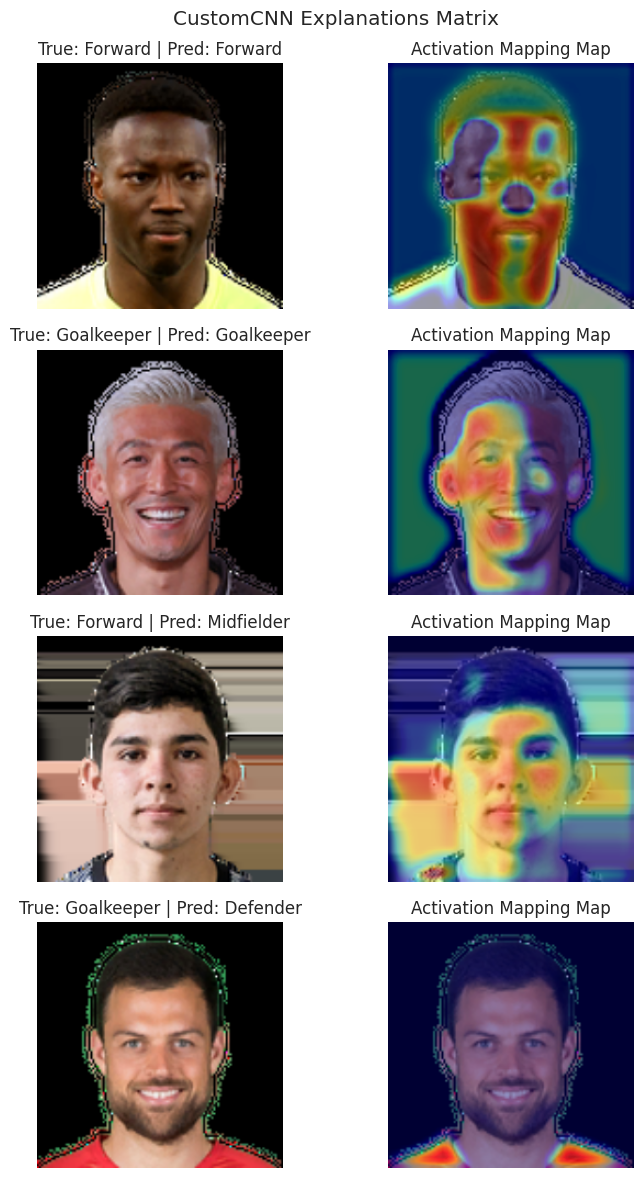

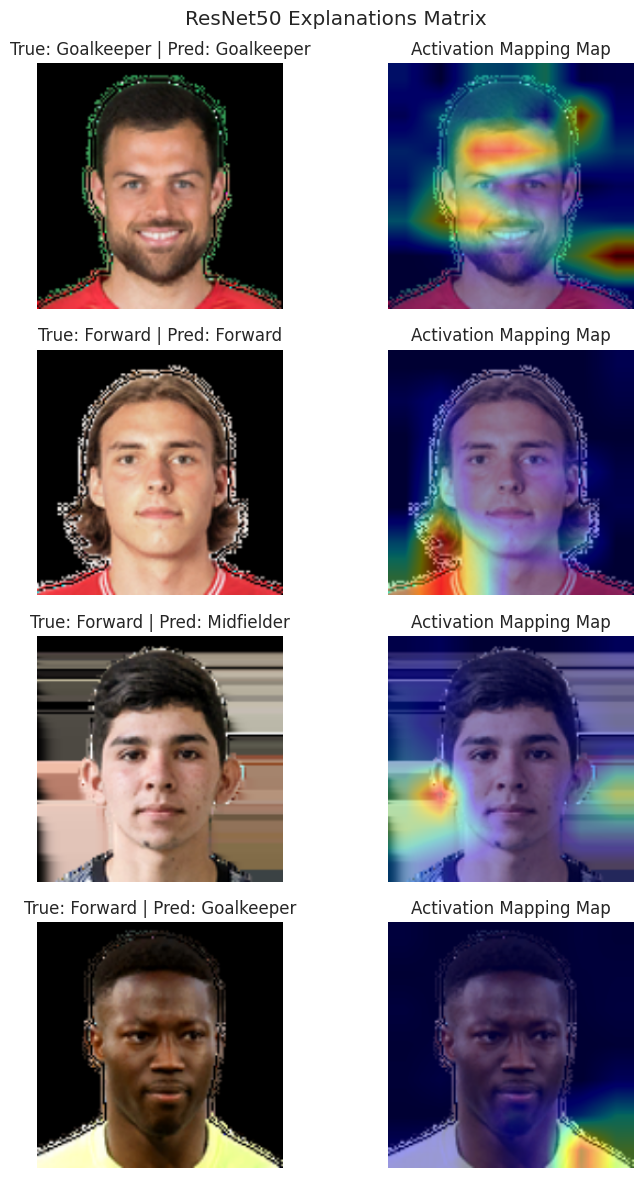

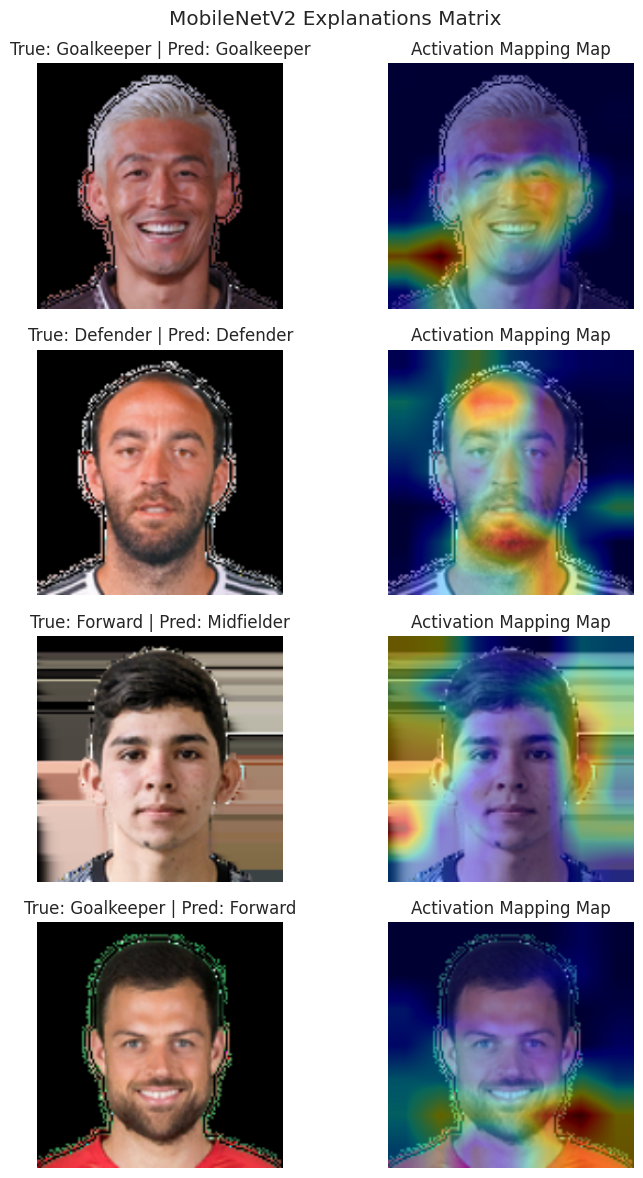

In [21]:
# %% [code]
def read_single_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    return tf.cast(image, tf.float32)

def generate_gradcam_heatmap(model, config, image_batch, class_index):
    if config['type'] == 'custom':
        target_layer = model.get_layer(config['last_conv'])
        grad_model = keras.Model(inputs=model.inputs, outputs=[target_layer.output, model.output])
        
        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(image_batch, training=False)
            loss = predictions[:, class_index]
    else:
        # Prevent graph tracing fragmentation inside nested pre-trained transfer layers
        base_model = model.get_layer(config['base_name'])
        target_layer = base_model.get_layer(config['last_conv'])
        preprocess_layer = model.get_layer(f"{model.name}_preprocess")
        
        base_grad_model = keras.Model(inputs=base_model.inputs, outputs=[target_layer.output, base_model.output])
        
        with tf.GradientTape() as tape:
            preprocessed_input = preprocess_layer(image_batch)
            conv_outputs, base_outputs = base_grad_model(preprocessed_input, training=False)
            
            x = model.get_layer(f"{model.name}_gap")(base_outputs)
            x = model.get_layer(f"{model.name}_dropout")(x, training=False)
            predictions = model.get_layer(f"{model.name}_classifier")(x)
            loss = predictions[:, class_index]
            
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1).numpy()
    
    heatmap = np.maximum(heatmap, 0)
    max_val = np.max(heatmap)
    if max_val == 0:
        max_val = 1e-8
    return heatmap / max_val

def overlay_heatmap(image, heatmap, alpha=0.40):
    image_uint8 = np.clip(image, 0, 255).astype('uint8')
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    cmap = plt.get_cmap('jet')
    heatmap_rgb = cmap(heatmap_resized)[..., :3] * 255
    overlay = heatmap_rgb * alpha + image_uint8 * (1 - alpha)
    return np.clip(overlay, 0, 255).astype('uint8')

def render_and_save_gradcam(model_name, config, count_each=2):
    preds = prediction_cache[model_name]
    df_eval = test_df.reset_index(drop=True).copy()
    df_eval['true_label'] = preds['y_true']
    df_eval['pred_label'] = preds['y_pred']
    df_eval['is_correct'] = df_eval['true_label'] == df_eval['pred_label']
    
    correct_samples = df_eval[df_eval['is_correct']].head(count_each)
    incorrect_samples = df_eval[~df_eval['is_correct']].head(count_each)
    samples = pd.concat([correct_samples, incorrect_samples], ignore_index=True)
    
    if len(samples) == 0: 
        return
        
    fig, axes = plt.subplots(len(samples), 2, figsize=(8, 3 * len(samples)))
    for idx, (_, row) in enumerate(samples.iterrows()):
        img = read_single_image(row['image_path'])
        heatmap = generate_gradcam_heatmap(config['model'], config, tf.expand_dims(img, axis=0), int(row['pred_label']))
        overlay = overlay_heatmap(img.numpy(), heatmap)
        
        axes[idx, 0].imshow(img.numpy().astype('uint8'))
        axes[idx, 0].set_title(f"True: {ID_TO_ROLE[int(row['true_label'])]} | Pred: {ID_TO_ROLE[int(row['pred_label'])]}")
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(overlay)
        axes[idx, 1].set_title('Activation Mapping Map')
        axes[idx, 1].axis('off')
        
    plt.suptitle(f'{model_name} Explanations Matrix')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f'{model_name}_gradcam.pdf', format='pdf', bbox_inches='tight')
    plt.show()

for model_name, config in model_configs.items():
    render_and_save_gradcam(model_name, config)

Cell 12: Directory Content and Execution Receipt Check

Initializing SHAP Image Interpretation Engine...
Calculating pixel attributions...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  33%|███▎      | 1/3 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 3/3 [00:30<00:00,  7.47s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [00:45, 15.23s/it]                       


Generating SHAP Attribution Plots...


<Figure size 1200x800 with 0 Axes>

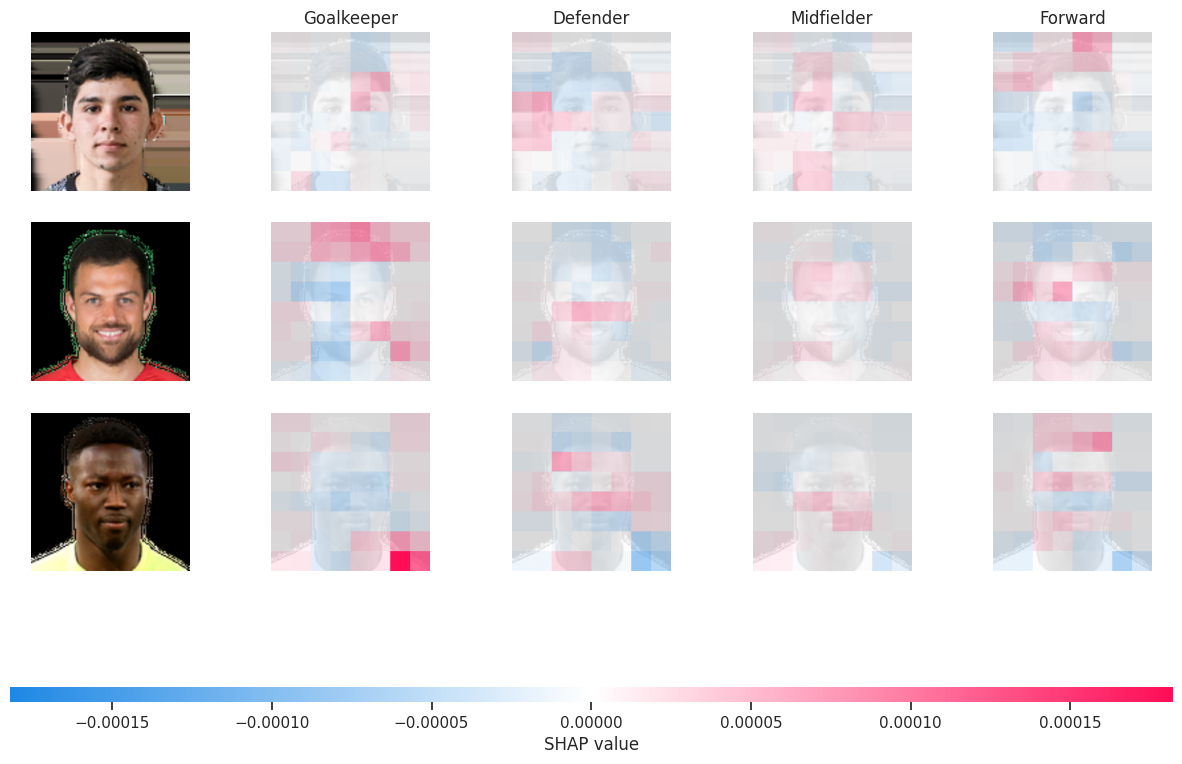

✓ SHAP visualization successfully exported to: /kaggle/working/figures/shap_interpretability_matrix.pdf


In [23]:
# %% [code]
print("Initializing SHAP Image Interpretation Engine...")

# 1. Grab a sample batch
test_images, test_labels = next(iter(test_ds.take(1)))
images_numpy = test_images.numpy()

# Select indices to explain
indices_to_explain = [0, 1, 2]
sample_images = images_numpy[indices_to_explain]

# 2. Define prediction wrapper
# Ensure the model receives the same preprocessing as it did during training
active_model = model_configs['ResNet50']['model']  

def predict_wrapper(img_batch):
    # If your model expects [0, 255] range, pass as is.
    # If your model expects [0, 1] range, ensure you divide by 255.0 here.
    return active_model.predict(img_batch, verbose=0)

# 3. Configure SHAP
masker = shap.maskers.Image("inpaint_telea", sample_images[0].shape)
explainer = shap.Explainer(predict_wrapper, masker, output_names=ROLE_NAMES)

# 4. Calculate SHAP Values
print("Calculating pixel attributions...")
shap_values = explainer(sample_images, max_evals=500, batch_size=BATCH_SIZE)

# 5. Render and Save with Normalization Fix
print("Generating SHAP Attribution Plots...")

# Ensure images are in [0, 1] float range for SHAP plotting to avoid clipping warnings
plot_images = sample_images / 255.0 if sample_images.max() > 1.0 else sample_images

plt.figure(figsize=(12, 8))
# image_plot now receives normalized data
shap.image_plot(shap_values, plot_images, show=False)

output_path = FIGURE_DIR / 'shap_interpretability_matrix.pdf'
plt.savefig(output_path, bbox_inches='tight', format='pdf')
plt.show()

print(f"✓ SHAP visualization successfully exported to: {output_path}")

In [24]:
# %% [code]
print('=== Verification Summary ===')
print(f"Generated Tables: {len(os.listdir(TABLE_DIR))}")
print(f"Generated Visual Figures: {len(os.listdir(FIGURE_DIR))}")
print(f"Compiled Checkpoints: {len(os.listdir(MODEL_DIR))}")

=== Verification Summary ===
Generated Tables: 12
Generated Visual Figures: 5
Compiled Checkpoints: 6


In [25]:
# %% [code]
import zipfile
import os
from IPython.display import FileLink

# Define the target directory to zip (all your work)
output_filename = 'project_full_export.zip'
dir_to_zip = '/kaggle/working/'

print(f"Archiving project files into {output_filename}...")

with zipfile.ZipFile(output_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(dir_to_zip):
        for file in files:
            # Skip the zip file itself if it's already there
            if file == output_filename:
                continue
            # Construct full file path
            file_path = os.path.join(root, file)
            # Add file to zip (arcname is the path inside the zip)
            zipf.write(file_path, os.path.relpath(file_path, dir_to_zip))

print("✓ Archiving complete.")

# Create a clickable download link
display(FileLink(output_filename))

Archiving project files into project_full_export.zip...
✓ Archiving complete.


/kaggle/working/project_full_export.zip